In [ ]:
import numpy as np
import numpy.random as random
import pandas as pd
import xgboost as xgb
from pandas import Series, DataFrame
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

In [2]:
sales = pd.read_csv("../data/sales.csv")
sample = pd.read_csv("../data/sample_submission.csv")

In [3]:
sales.set_index("Date", inplace=True)
sales.index = pd.to_datetime(sales.index)

In [4]:
sales

,Revenue,COGS
Date,,
2012-07-04,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79
...,...,...
2022-12-27,2100553.66,2184872.24
2022-12-28,3448729.20,3513621.00
2022-12-29,3083944.33,3170787.10


In [5]:
train = sales.loc[sales.index <= '01-01-2021']
test = sales.loc[sales.index > '01-01-2021']

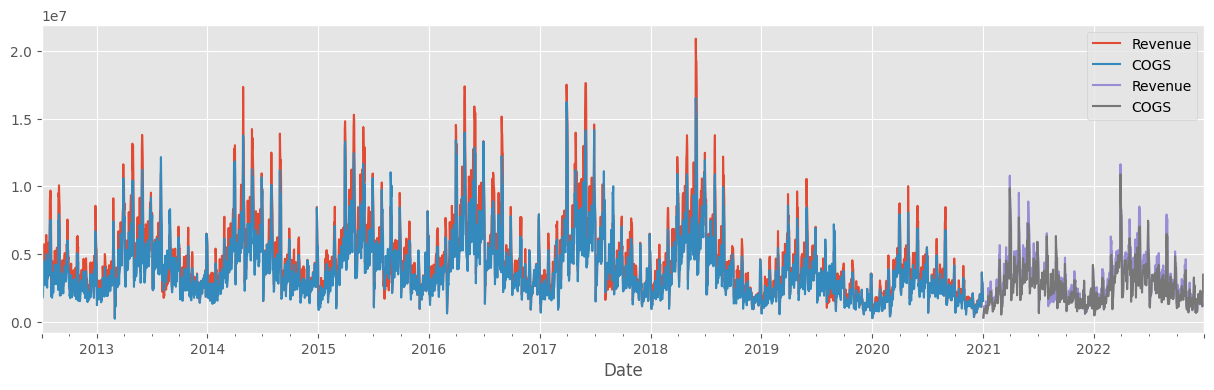

In [6]:
fig, ax = plt.subplots(figsize=(15,4))
train.plot(ax=ax,label = 'Training Set')
test.plot(ax=ax, label = 'Test Set')
plt.show()

<Axes: xlabel='Date'>

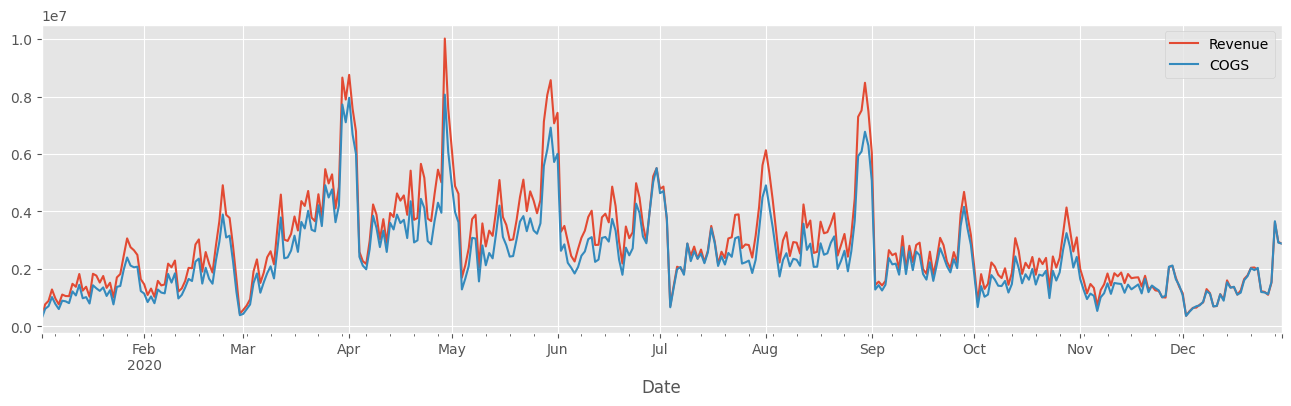

In [7]:
sales.loc[(sales.index > '01-01-2020') & (sales.index < '12-31-2020')].plot(figsize=(16,4))

<Axes: xlabel='Date'>

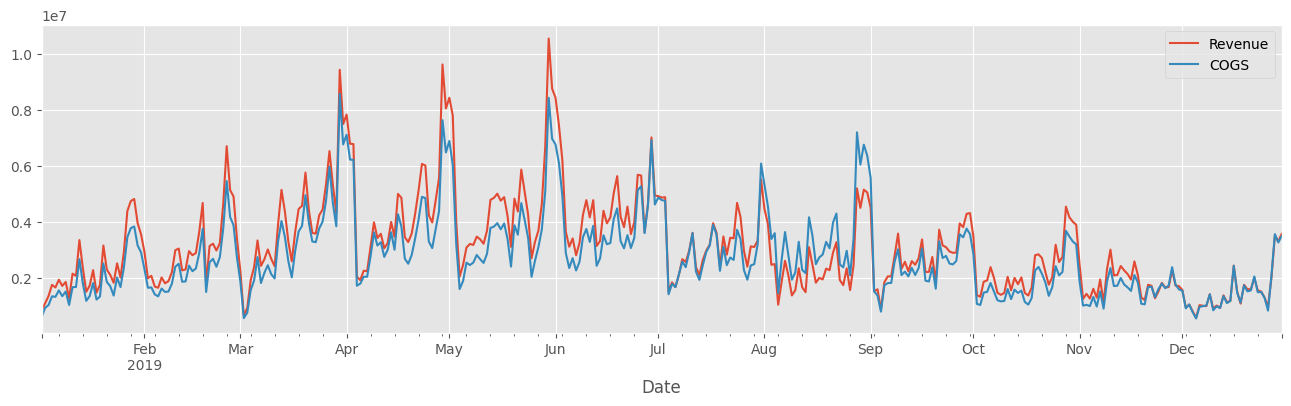

In [8]:
sales.loc[(sales.index > '01-01-2019') & (sales.index < '12-31-2019')].plot(figsize=(16,4))

three big spikes: april may jun (maybe september). Start of everymonth tends to have a spike.

In [17]:
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['day'] = df.index.day
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['quarter'] = df.index.quarter
    df['is_post_covid'] = (df['year'] >= 2019).astype(int)
    
    if 'Revenue' in df.columns:
        df['revenue_last_year'] = df['Revenue'].shift(365)
    if 'COGS' in df.columns:
        df['cogs_last_year'] = df['COGS'].shift(365)

    df['revenue_roll_mean_90'] = df['Revenue'].shift(365).rolling(window=90).mean()
    
    return df

In [18]:
sales = create_features(sales)
sales.head(10)

,Revenue,COGS,dayofweek,day,month,year,quarter,is_post_covid,revenue_last_year,revenue_roll_mean_90,cogs_last_year
Date,,,,,,,,,,,
2012-07-04,5123547.94,3982991.19,2,4,7,2012,3,0,NaN,NaN,NaN
2012-07-05,2751773.45,2150580.23,3,5,7,2012,3,0,NaN,NaN,NaN
2012-07-06,3054029.42,2517632.84,4,6,7,2012,3,0,NaN,NaN,NaN
2012-07-07,2667930.94,2108246.62,5,7,7,2012,3,0,NaN,NaN,NaN
2012-07-08,2360851.90,1808622.79,6,8,7,2012,3,0,NaN,NaN,NaN
2012-07-09,3548386.46,2787841.68,0,9,7,2012,3,0,NaN,NaN,NaN
2012-07-10,5234938.62,4044438.84,1,10,7,2012,3,0,NaN,NaN,NaN
2012-07-11,5582884.78,4338313.07,2,11,7,2012,3,0,NaN,NaN,NaN
2012-07-12,5734632.02,4458811.27,3,12,7,2012,3,0,NaN,NaN,NaN


In [19]:
train = create_features(train)
test = create_features(test)

In [20]:

FEATURES_REV = ['dayofweek', 'day', 'month', 'year', 'quarter','is_post_covid', 'revenue_last_year','revenue_roll_mean_90']
FEATURES_COGS = ['dayofweek', 'day', 'month', 'year', 'quarter','is_post_covid', 'cogs_last_year','revenue_roll_mean_90']
TARGET_REV = 'Revenue'
TARGET_COGS = "COGS"

In [21]:
X_train_rev = train[FEATURES_REV]
y_train_rev = train[TARGET_REV]

X_test_rev = test[FEATURES_REV]
y_test_rev = test[TARGET_REV]

In [23]:
X_train_rev.head(10)

,dayofweek,day,month,year,quarter,is_post_covid,revenue_last_year,revenue_roll_mean_90
Date,,,,,,,,
2012-07-04,2,4,7,2012,3,0,NaN,NaN
2012-07-05,3,5,7,2012,3,0,NaN,NaN
2012-07-06,4,6,7,2012,3,0,NaN,NaN
2012-07-07,5,7,7,2012,3,0,NaN,NaN
2012-07-08,6,8,7,2012,3,0,NaN,NaN
2012-07-09,0,9,7,2012,3,0,NaN,NaN
2012-07-10,1,10,7,2012,3,0,NaN,NaN
2012-07-11,2,11,7,2012,3,0,NaN,NaN
2012-07-12,3,12,7,2012,3,0,NaN,NaN


In [24]:
X_train_cogs = train[FEATURES_COGS]
y_train_cogs = train[TARGET_COGS]

X_test_cogs = test[FEATURES_COGS]
y_test_cogs = test[TARGET_COGS]

## TASK CẦN LÀM:
1. Tìm parameters tối ưu cho model (GridSearchCV or sth)
2. Feature Engineering: Xử lý NaN, nghĩ thêm biến từ các csv khác
3. Viết report

In [38]:
reg_rev = xgb.XGBRegressor(n_estimators = 1500,
                        early_stopping_rounds = 150,
                        learning_rate = 0.04)
reg_rev.fit(X_train_rev,
        y_train_rev,
        eval_set = [(X_train_rev,y_train_rev),(X_test_rev,y_test_rev)],
        verbose = 100)

[0]	validation_0-rmse:2640677.77866	validation_1-rmse:2227127.03007


[100]	validation_0-rmse:846740.26092	validation_1-rmse:1314541.48938
[200]	validation_0-rmse:652075.47018	validation_1-rmse:1233005.34458
[300]	validation_0-rmse:555410.71569	validation_1-rmse:1200195.66590
[400]	validation_0-rmse:493517.84815	validation_1-rmse:1194371.85396
[500]	validation_0-rmse:440212.45963	validation_1-rmse:1199766.52004
[600]	validation_0-rmse:397499.55594	validation_1-rmse:1184924.11889
[700]	validation_0-rmse:357074.91170	validation_1-rmse:1176416.43634
[800]	validation_0-rmse:326843.79300	validation_1-rmse:1151873.45471
[900]	validation_0-rmse:301418.87284	validation_1-rmse:1147779.18776
[1000]	validation_0-rmse:281216.85018	validation_1-rmse:1149614.00078
[1012]	validation_0-rmse:277556.67974	validation_1-rmse:1150340.78025


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",150
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [40]:
reg_cogs = xgb.XGBRegressor(n_estimators = 1500,
                             early_stopping_rounds = 150, 
                             learning_rate = 0.04)
reg_cogs.fit(X_train_cogs,
        y_train_cogs,
        eval_set = [(X_train_cogs,y_train_cogs),(X_test_cogs,y_test_cogs)],
        verbose = 100)

[0]	validation_0-rmse:2231875.77559	validation_1-rmse:1868918.67796


[100]	validation_0-rmse:685883.97261	validation_1-rmse:1037539.38306
[200]	validation_0-rmse:530301.01065	validation_1-rmse:975183.43287
[300]	validation_0-rmse:452344.19642	validation_1-rmse:951243.31472
[400]	validation_0-rmse:398617.23675	validation_1-rmse:946143.60219
[500]	validation_0-rmse:356846.89078	validation_1-rmse:944464.13179
[600]	validation_0-rmse:323096.52461	validation_1-rmse:937679.91994
[700]	validation_0-rmse:295953.85392	validation_1-rmse:932715.03397
[800]	validation_0-rmse:271350.15848	validation_1-rmse:934062.72033
[900]	validation_0-rmse:253710.79552	validation_1-rmse:934618.59877
[914]	validation_0-rmse:251632.65342	validation_1-rmse:934753.16514


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",150
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

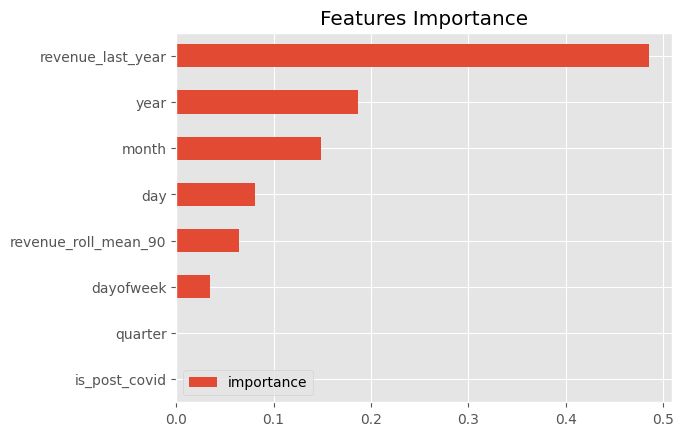

In [41]:
f1_rev = pd.DataFrame(data = reg_rev.feature_importances_,
                  index = reg_rev.feature_names_in_,
                  columns=['importance'])
f1_rev.sort_values('importance').plot(kind = 'barh', title='Features Importance')
plt.show()

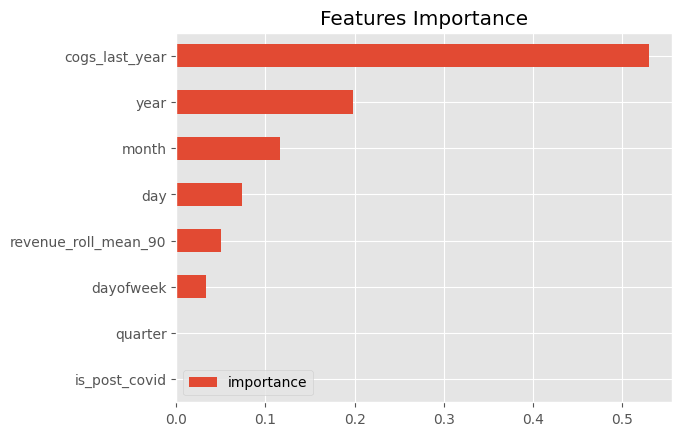

In [42]:
f1_cogs = pd.DataFrame(data = reg_cogs.feature_importances_,
                  index = reg_cogs.feature_names_in_,
                  columns=['importance'])
f1_cogs.sort_values('importance').plot(kind = 'barh', title='Features Importance')
plt.show()

In [43]:
def evaluate_model(y_true, y_pred, label="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {label} Evaluation ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2:  {r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

evaluate_model(y_test_cogs,reg_cogs.predict(X_test_cogs), 'Cogs Model')
evaluate_model(y_test_rev, reg_rev.predict(X_test_rev), "Revenue Model")

--- Cogs Model Evaluation ---
MAE:  740172.12
RMSE: 931839.45
R^2:  0.5874
--- Revenue Model Evaluation ---
MAE:  883042.77
RMSE: 1144607.75
R^2:  0.5287


{'MAE': 883042.766, 'RMSE': 1144607.748, 'R2': 0.529}

In [45]:
future_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
future_df = pd.DataFrame(index=future_dates)
future_df.index.name = 'Date'

full_df = pd.concat([sales, future_df])
full_df = create_features(full_df) 

X_future_rev = full_df.loc['2023-01-01':'2024-07-01'][FEATURES_REV]
X_future_cogs = full_df.loc['2023-01-01':'2024-07-01'][FEATURES_COGS]

future_df['Revenue'] = reg_rev.predict(X_future_rev)
future_df['COGS'] = reg_cogs.predict(X_future_cogs)

# 5. Xuất file
future_df[['Revenue', 'COGS']].to_csv('../data/my_submission.csv')

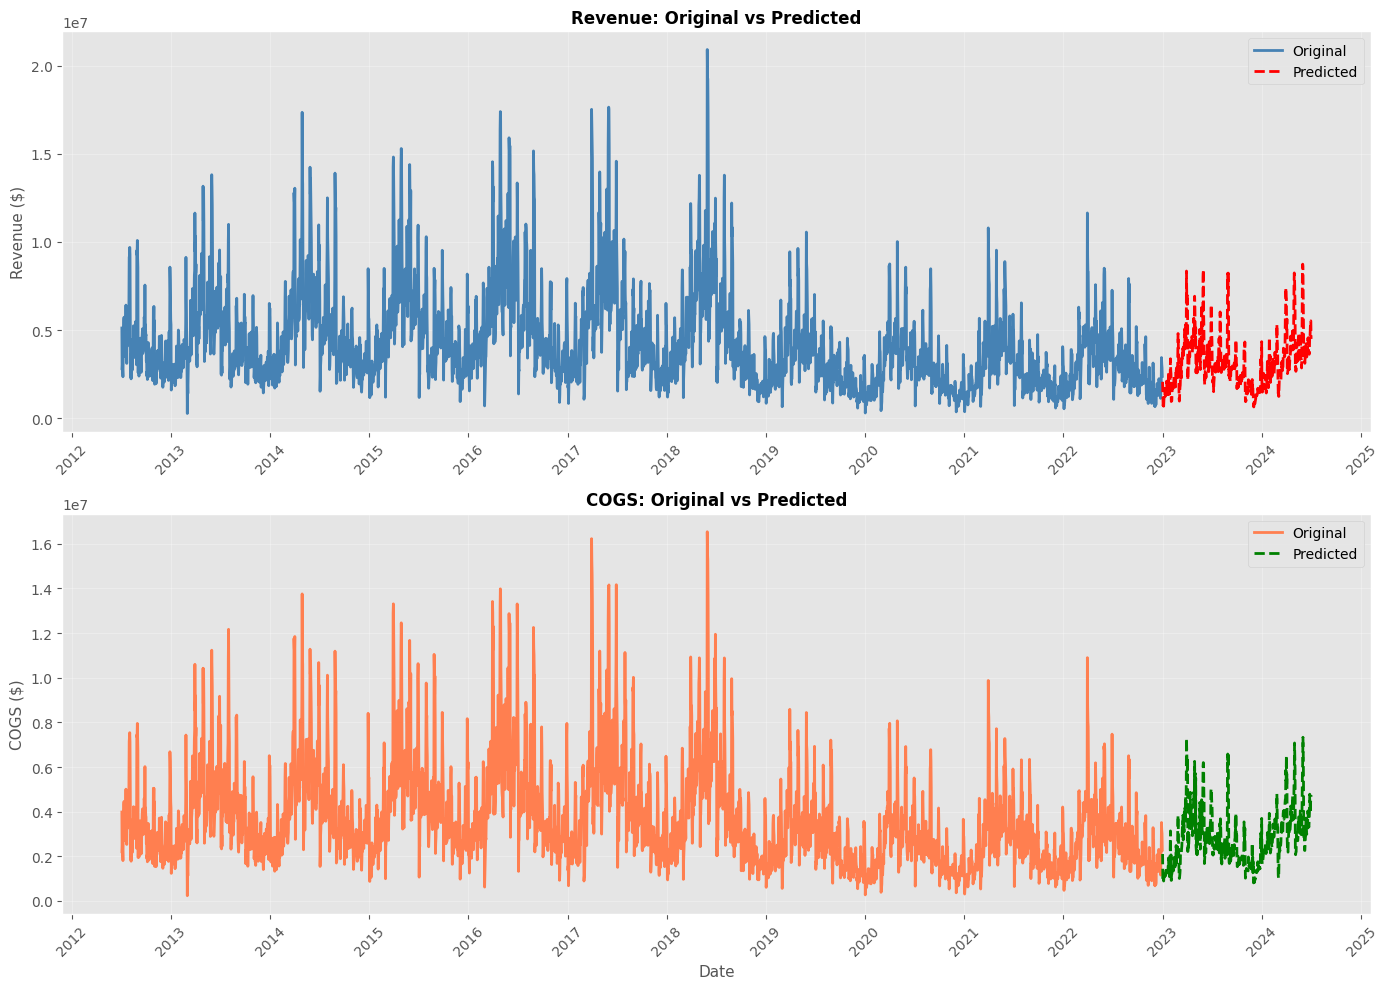

In [48]:
# Load both datasets
sales_original = pd.read_csv("../data/sales.csv")
sales_original['Date'] = pd.to_datetime(sales_original['Date'])

predicted = pd.read_csv("../data/my_submission.csv")
predicted['Date'] = pd.to_datetime(predicted['Date'])

# Create the plots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue
axes[0].plot(sales_original['Date'], sales_original['Revenue'], linewidth=2, color='steelblue', label='Original')
axes[0].plot(predicted['Date'], predicted['Revenue'], linewidth=2, color='red', linestyle='--', label='Predicted')
axes[0].set_title('Revenue: Original vs Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].tick_params(axis='x', rotation=45)

# COGS
axes[1].plot(sales_original['Date'], sales_original['COGS'], linewidth=2, color='coral', label='Original')
axes[1].plot(predicted['Date'], predicted['COGS'], linewidth=2, color='green', linestyle='--', label='Predicted')
axes[1].set_title('COGS: Original vs Predicted', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('COGS ($)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()